# Extrovert Introvert Dataset EDA

**Table of Contents**<a id='toc0_'></a>
- [Introduction](#toc1_)
	- [Examining Data Types and Structures](#toc1_1_)
	- [Handling Missing Data](#toc1_2_)
	- [De-Duplication](#toc1_3_)
	- [Handling Data-Irregularities](#toc1_4_)

## <a id='toc1_'></a>[1. Introduction](#toc0_)

This is an EDA task that we wanna do some exploratory data analysis on the personality dataset. the following analysis include below sections:
- ~~examining data types and structures~~
- ~~handling missing data (data cleaning)~~
- ~~de-duplication~~
- handling data-irregularities (outliers, anomaly, novelty, data drift)
- feature creation
- feature transformation
- feature extraction (future)
- feature selection (future)


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import missingno
import preprocessing as pr

In [2]:
import sklearn

# sklearn version used in this project
sklearn.__version__

'1.8.0'

In [3]:
df = pd.read_csv("/mnt/d/Pytopia/Machine Learning/Applied-ML-Lab/data/raw/personality_dataset.csv")
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


**Features:**
- `Time_spent_Alone`: Hours spent alone daily (0–11).
- `Stage_fear`: Presence of stage fright (Yes/No).
- `Social_event_attendance`: Frequency of social events (0–10).
- `Going_outside`: Frequency of going outside (0–7).
- `Drained_after_socializing`: Feeling drained after socializing (Yes/No).
- `Friends_circle_size`: Number of close friends (0–15).
- `Post_frequency`: Social media post frequency (0–10).
- `Personality`: Target variable (Extrovert/Introvert).*

In [4]:
print("shape of the dataset:")
df.shape

shape of the dataset:


(2900, 8)

### <a id='toc1_1_'></a>[1.1. Examining Data Types and Structures](#toc0_)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2837 non-null   float64
 1   Stage_fear                 2827 non-null   str    
 2   Social_event_attendance    2838 non-null   float64
 3   Going_outside              2834 non-null   float64
 4   Drained_after_socializing  2848 non-null   str    
 5   Friends_circle_size        2823 non-null   float64
 6   Post_frequency             2835 non-null   float64
 7   Personality                2900 non-null   str    
dtypes: float64(5), str(3)
memory usage: 181.4 KB


In [6]:
# normalizing text data
df['Stage_fear'] = df['Stage_fear'].str.lower()
df['Drained_after_socializing'] = df['Drained_after_socializing'].str.lower()
df['Personality'] = df['Personality'].str.lower()

df['Drained_after_socializing'] = df['Drained_after_socializing'].astype("category")
df['Stage_fear'] = df['Stage_fear'].astype("category")
df['Personality'] = df['Personality'].astype("category")
df

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,no,4.0,6.0,no,13.0,5.0,extrovert
1,9.0,yes,0.0,0.0,yes,0.0,3.0,introvert
2,9.0,yes,1.0,2.0,yes,5.0,2.0,introvert
3,0.0,no,6.0,7.0,no,14.0,8.0,extrovert
4,3.0,no,9.0,4.0,no,8.0,5.0,extrovert
...,...,...,...,...,...,...,...,...
2895,3.0,no,7.0,6.0,no,6.0,6.0,extrovert
2896,3.0,no,8.0,3.0,no,14.0,9.0,extrovert
2897,4.0,yes,1.0,1.0,yes,4.0,0.0,introvert
2898,11.0,yes,1.0,NaN,yes,2.0,0.0,introvert


In [7]:
# fixed dtypes
df.dtypes

Time_spent_Alone              float64
Stage_fear                   category
Social_event_attendance       float64
Going_outside                 float64
Drained_after_socializing    category
Friends_circle_size           float64
Post_frequency                float64
Personality                  category
dtype: object

### <a id='toc1_2_'></a>[1.2. Handling Missing Data](#toc0_)

Text(0.5, 1.0, 'Nullity Matrix Plot')

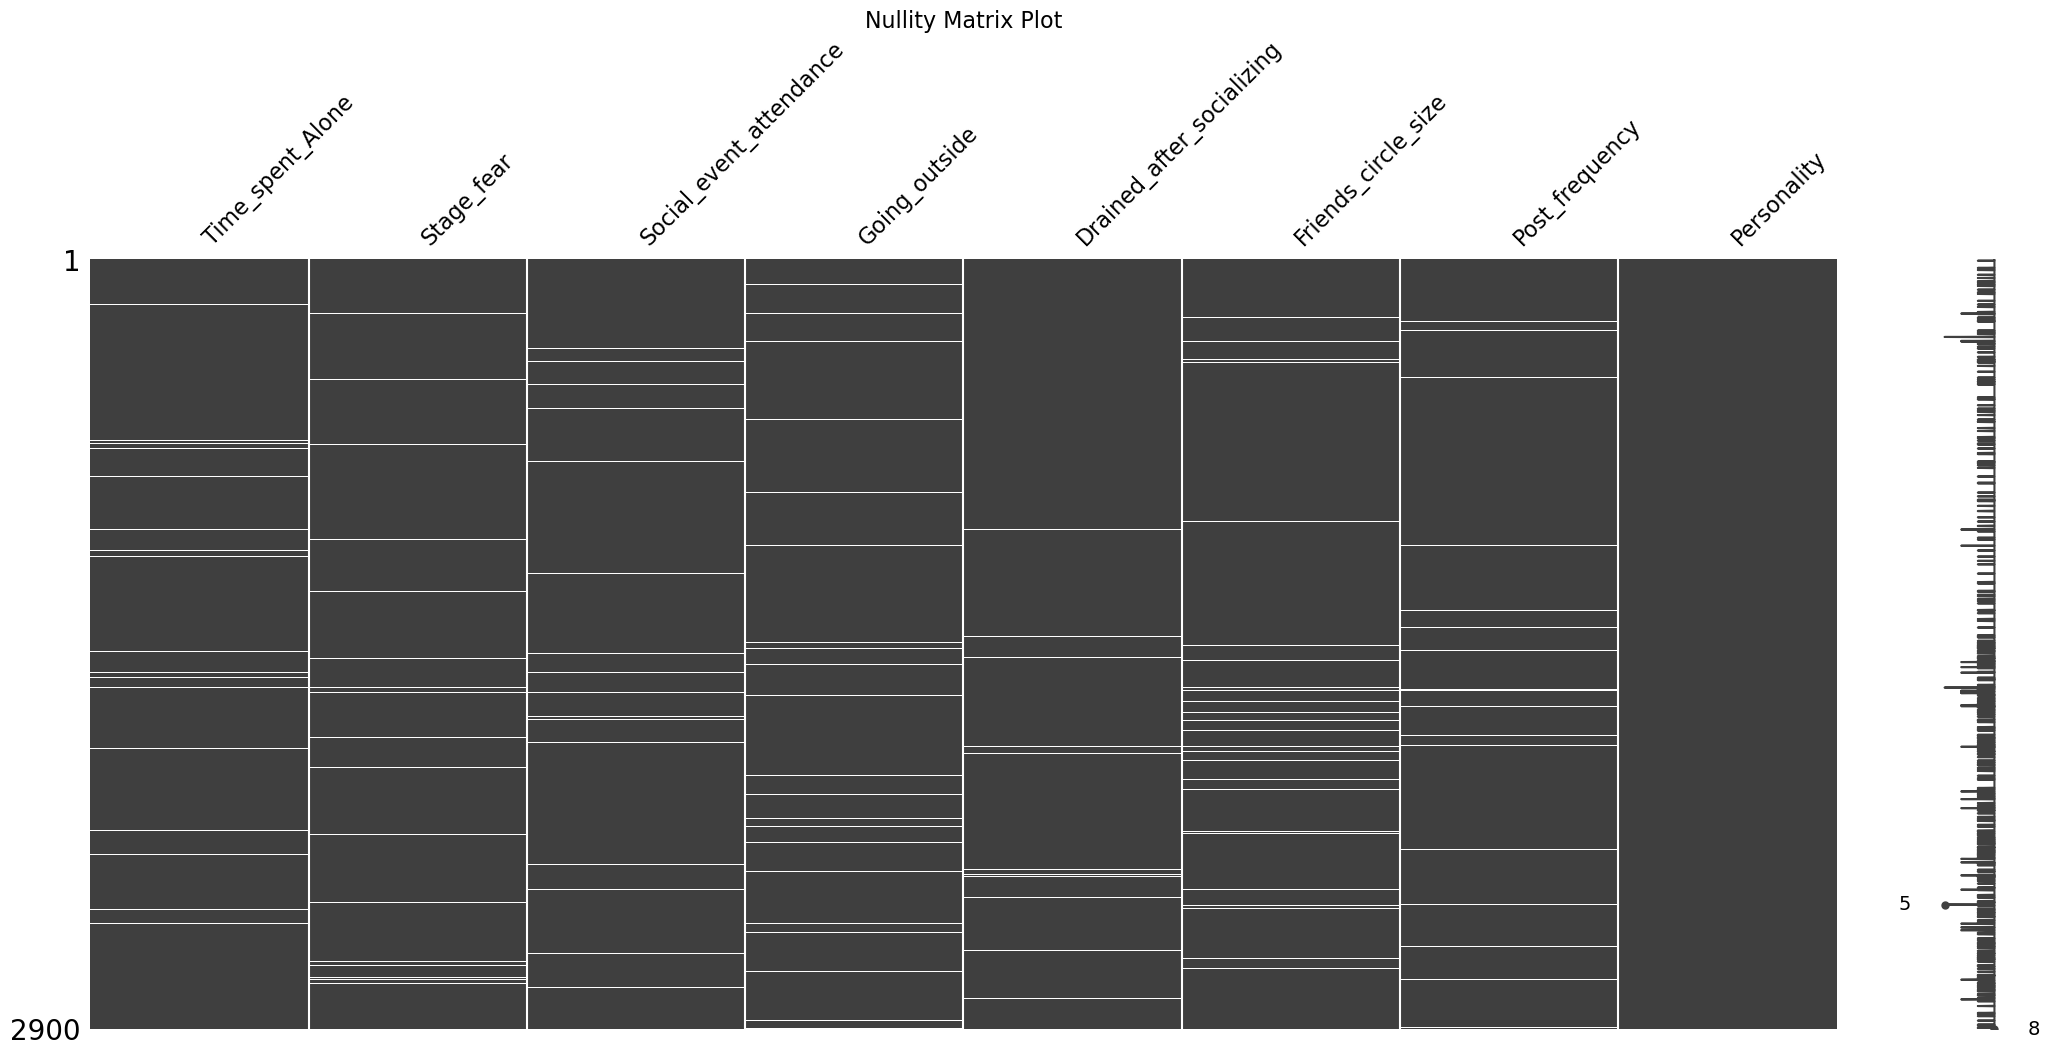

In [8]:
ax = missingno.matrix(df)
ax.set_title("Nullity Matrix Plot", fontsize=16)

In [9]:
pr.detect_mixed_types(df)

{'Stage_fear': {'str': 2827, 'float': 73},
 'Drained_after_socializing': {'str': 2848, 'float': 52}}

In [10]:
pr.missing_value_table(df)

Shape of the dataset: (2900, 8)
Number of Features with Missing Values: 7


,Missing Count,Missing Percentage
Friends_circle_size,77,2.655172
Stage_fear,73,2.517241
Going_outside,66,2.275862
Post_frequency,65,2.241379
Time_spent_Alone,63,2.172414
Social_event_attendance,62,2.137931
Drained_after_socializing,52,1.793103
Personality,0,0.000000


In [11]:
pr.categorize_missingness(df, 5)

Features with no missing values: ['Personality']
Features with lower than %5 missing values: ['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance', 'Going_outside', 'Drained_after_socializing', 'Friends_circle_size', 'Post_frequency']
Features with higher than %5 missing values: []


In [12]:
pr.describe(df)

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,2837.000000,2838.000000,2834.000000,2823.000000,2835.000000
mean,4.505816,3.963354,3.000000,6.268863,3.564727
median,4.000000,3.000000,3.000000,5.000000,3.000000
std,3.479192,2.903827,2.247327,4.289693,2.926582
variance,12.104779,8.432213,5.050477,18.401465,8.564881
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,3.000000,1.000000
50%,4.000000,3.000000,3.000000,5.000000,3.000000
75%,8.000000,6.000000,5.000000,10.000000,6.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000


Text(0.5, 1.0, 'Time_spent_Alone Distribution')

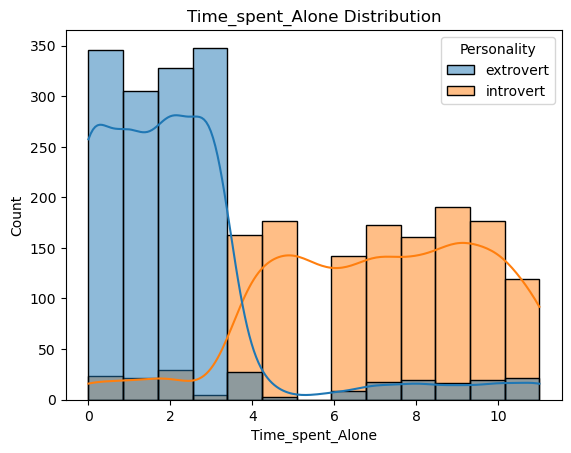

In [13]:
sns.histplot(data=df, x="Time_spent_Alone", kde=True, hue="Personality")
plt.title("Time_spent_Alone Distribution")

In [14]:
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,no,4.0,6.0,no,13.0,5.0,extrovert
1,9.0,yes,0.0,0.0,yes,0.0,3.0,introvert
2,9.0,yes,1.0,2.0,yes,5.0,2.0,introvert
3,0.0,no,6.0,7.0,no,14.0,8.0,extrovert
4,3.0,no,9.0,4.0,no,8.0,5.0,extrovert


In [15]:
# impute missing values by the mean for each personality category
introverts_median_time_spent_alone = df[df['Personality'] == "introvert"]['Time_spent_Alone'].median()
extroverts_median_time_spent_alone = df[df['Personality'] == "extrovert"]['Time_spent_Alone'].median()
df_clean = df.copy()

df_clean.loc[
    ((df_clean['Time_spent_Alone'].isnull()) & (df_clean['Personality'] == "introvert")),
    "Time_spent_Alone"
] = introverts_median_time_spent_alone
df_clean.loc[
    ((df_clean['Time_spent_Alone'].isnull()) & (df_clean['Personality'] == "extrovert")),
    "Time_spent_Alone"
] = extroverts_median_time_spent_alone
print(f"number of null values in `Time_spent_Alone`:{df_clean['Time_spent_Alone'].isnull().sum()}")

number of null values in `Time_spent_Alone`:0


Text(0.5, 1.0, 'Imputed with Median')

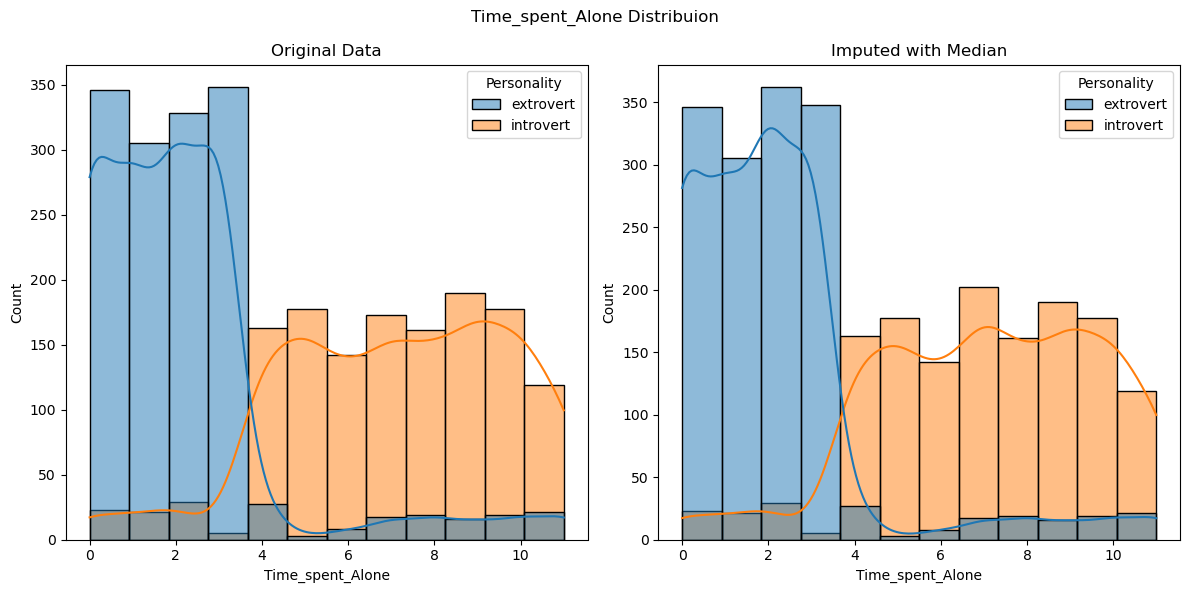

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), tight_layout=True)
plt.suptitle("Time_spent_Alone Distribuion")

bin = 12

sns.histplot(data=df, x="Time_spent_Alone", hue="Personality", kde=True, bins=bin, ax=ax1)
ax1.set_title("Original Data")

sns.histplot(data=df_clean, x="Time_spent_Alone", hue="Personality", kde=True, bins=bin, ax=ax2)
ax2.set_title("Imputed with Median")

Based-on this fact that it makes sense to impute `time spent alone` null values based-on each personality type so we impute the null values using median of the time spent alone feature for each personality type.

In [17]:
df_clean.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,no,4.0,6.0,no,13.0,5.0,extrovert
1,9.0,yes,0.0,0.0,yes,0.0,3.0,introvert
2,9.0,yes,1.0,2.0,yes,5.0,2.0,introvert
3,0.0,no,6.0,7.0,no,14.0,8.0,extrovert
4,3.0,no,9.0,4.0,no,8.0,5.0,extrovert


In [18]:
print("Stage fear missing values:\n")
print(
    "number of null values for introvert personality:",
    df_clean.loc[(df_clean['Stage_fear'].isnull()) & (df_clean['Personality'] == "introvert")].shape[0]
)
print(
    "number of null values for extrovert personality:",
df_clean.loc[(df_clean['Stage_fear'].isnull()) & (df_clean['Personality'] == "extrovert")].shape[0]
)

Stage fear missing values:

number of null values for introvert personality: 31
number of null values for extrovert personality: 42


In [19]:
df_clean.loc[
    (df['Personality'] == "introvert") & (df['Stage_fear'].isnull()),
    "Stage_fear"
] = "yes"
df_clean.loc[
    (df['Personality'] == "extrovert") & (df['Stage_fear'].isnull()),
    "Stage_fear"
] = "no"

print(df_clean.loc[:, "Stage_fear"].isnull().sum()) # no missing values remained
df_clean.head()

0


,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,no,4.0,6.0,no,13.0,5.0,extrovert
1,9.0,yes,0.0,0.0,yes,0.0,3.0,introvert
2,9.0,yes,1.0,2.0,yes,5.0,2.0,introvert
3,0.0,no,6.0,7.0,no,14.0,8.0,extrovert
4,3.0,no,9.0,4.0,no,8.0,5.0,extrovert


Text(0.5, 1.0, 'Social Event Attendance by Personality')

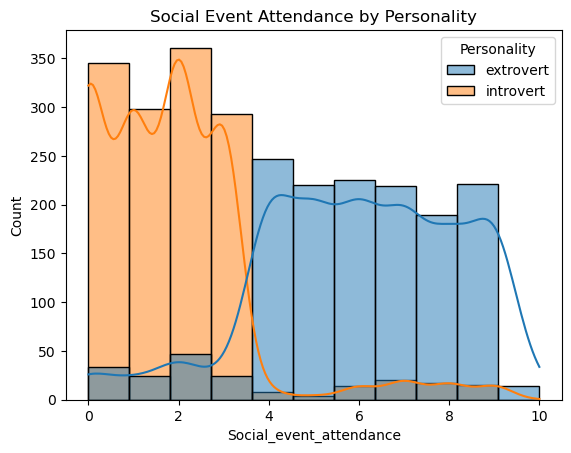

In [20]:
sns.histplot(
    data=df_clean,
    x="Social_event_attendance",
    hue="Personality",
    kde=True,
    bins=11
)
plt.title("Social Event Attendance by Personality")

In [21]:
introverts_median_social_event_attendace = df_clean.loc[(df_clean['Personality'] == "introvert"), "Social_event_attendance"].median()
extroverts_median_social_event_attendace = df_clean.loc[(df_clean['Personality'] == "extrovert"), "Social_event_attendance"].median()

df_clean.loc[
    (df_clean['Personality'] == "introvert") & (df_clean['Social_event_attendance'].isnull()),
    "Social_event_attendance"
] = introverts_median_social_event_attendace
df_clean.loc[
    (df_clean['Personality'] == "extrovert") & (df_clean['Social_event_attendance'].isnull()),
    "Social_event_attendance"
] = extroverts_median_social_event_attendace

print(df_clean.loc[:, "Social_event_attendance"].isnull().sum())
df_clean.head()

0


,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,no,4.0,6.0,no,13.0,5.0,extrovert
1,9.0,yes,0.0,0.0,yes,0.0,3.0,introvert
2,9.0,yes,1.0,2.0,yes,5.0,2.0,introvert
3,0.0,no,6.0,7.0,no,14.0,8.0,extrovert
4,3.0,no,9.0,4.0,no,8.0,5.0,extrovert


In [22]:
df_clean.loc[
    (df['Personality'] == "introvert") & (df['Drained_after_socializing'].isnull()),
    'Drained_after_socializing'
] = "yes"
df_clean.loc[
    (df['Personality'] == "extrovert") & (df['Drained_after_socializing'].isnull()),
    'Drained_after_socializing'
] = "no"

print(df_clean.loc[:, 'Drained_after_socializing'].isnull().sum())
df_clean.head()

0


,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,no,4.0,6.0,no,13.0,5.0,extrovert
1,9.0,yes,0.0,0.0,yes,0.0,3.0,introvert
2,9.0,yes,1.0,2.0,yes,5.0,2.0,introvert
3,0.0,no,6.0,7.0,no,14.0,8.0,extrovert
4,3.0,no,9.0,4.0,no,8.0,5.0,extrovert


Text(0.5, 1.0, 'Friends Circle Size by Personality')

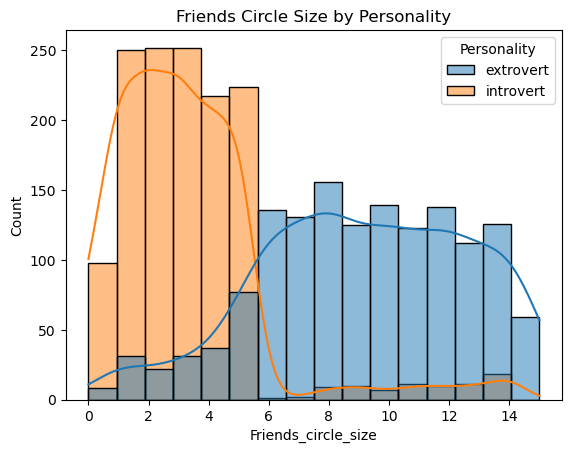

In [23]:
sns.histplot(
    data=df_clean,
    x="Friends_circle_size",
    hue="Personality",
    kde=True
)
plt.title("Friends Circle Size by Personality")

In [24]:
introverts_median_friends_circle_size = df_clean.loc[(df_clean['Personality'] == "introvert"), "Friends_circle_size"].median()
extroverts_median_friends_circle_size = df_clean.loc[(df_clean['Personality'] == "extrovert"), "Friends_circle_size"].median()

df_clean.loc[
    (df_clean['Personality'] == "introvert") & (df_clean['Friends_circle_size'].isnull()),
    'Friends_circle_size'
] = introverts_median_friends_circle_size
df_clean.loc[
    (df_clean['Personality'] == "extrovert") & (df_clean['Friends_circle_size'].isnull()),
    'Friends_circle_size'
] = extroverts_median_friends_circle_size

print(df_clean.loc[:, 'Friends_circle_size'].isnull().sum())
df_clean.head()

0


,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,no,4.0,6.0,no,13.0,5.0,extrovert
1,9.0,yes,0.0,0.0,yes,0.0,3.0,introvert
2,9.0,yes,1.0,2.0,yes,5.0,2.0,introvert
3,0.0,no,6.0,7.0,no,14.0,8.0,extrovert
4,3.0,no,9.0,4.0,no,8.0,5.0,extrovert


Text(0.5, 1.0, 'Imputed with Median Distribuion')

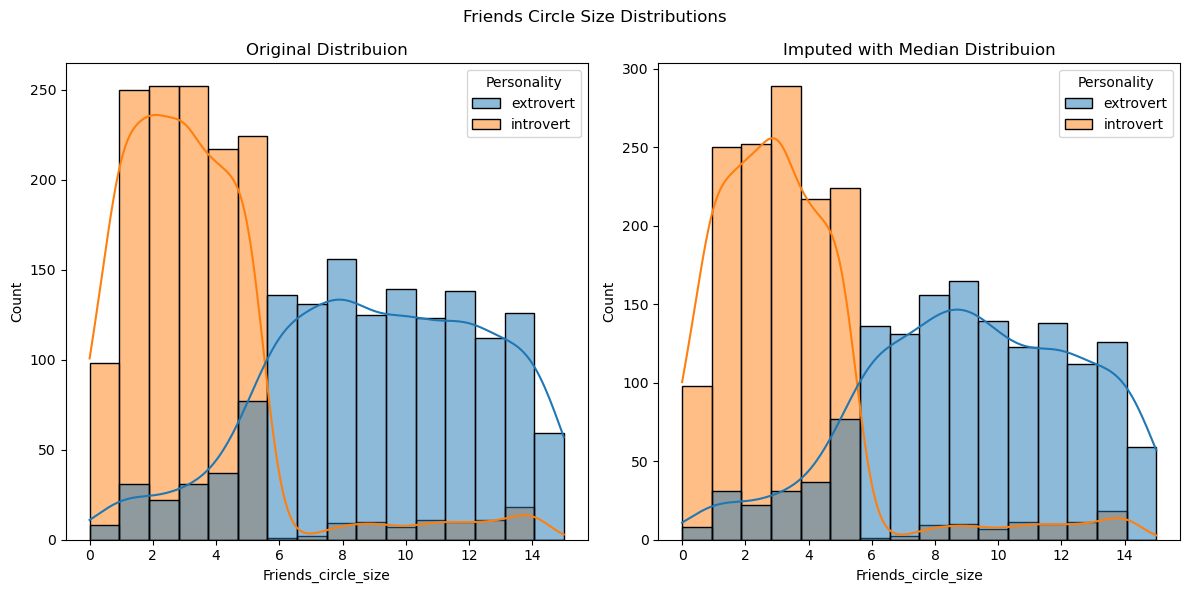

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), tight_layout=True)
plt.suptitle("Friends Circle Size Distributions")

sns.histplot(data=df, x="Friends_circle_size", hue="Personality", kde=True, ax=ax1)
ax1.set_title("Original Distribuion")

sns.histplot(data=df_clean, x="Friends_circle_size", hue="Personality", kde=True, ax=ax2)
ax2.set_title("Imputed with Median Distribuion")

Text(0.5, 1.0, 'Friends Circle Size by Personality')

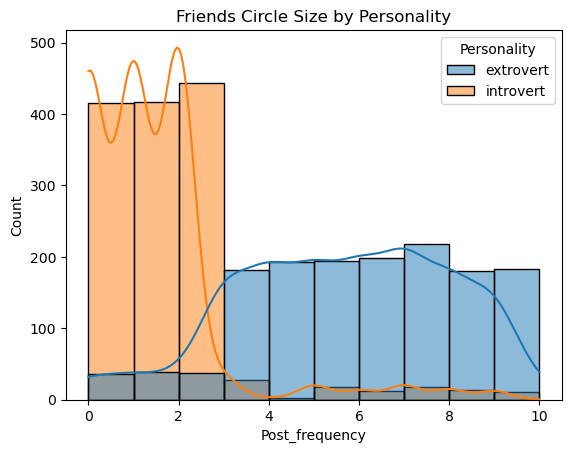

In [26]:
sns.histplot(
    data=df_clean,
    x="Post_frequency",
    hue="Personality",
    bins=10,
    kde=True
)
plt.title("Friends Circle Size by Personality")

In [27]:
introverts_median_post_frequency = df_clean.loc[(df_clean['Personality'] == "introvert"), "Post_frequency"].median()
extroverts_median_post_frequency = df_clean.loc[(df_clean['Personality'] == "extrovert"), "Post_frequency"].median()

df_clean.loc[
    (df_clean['Personality'] == "introvert") & (df_clean['Post_frequency'].isnull()),
    'Post_frequency'
] = introverts_median_friends_circle_size
df_clean.loc[
    (df_clean['Personality'] == "extrovert") & (df_clean['Post_frequency'].isnull()),
    'Post_frequency'
] = extroverts_median_friends_circle_size

print(df_clean.loc[:, 'Post_frequency'].isnull().sum())
df_clean.head()

0


,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,no,4.0,6.0,no,13.0,5.0,extrovert
1,9.0,yes,0.0,0.0,yes,0.0,3.0,introvert
2,9.0,yes,1.0,2.0,yes,5.0,2.0,introvert
3,0.0,no,6.0,7.0,no,14.0,8.0,extrovert
4,3.0,no,9.0,4.0,no,8.0,5.0,extrovert


Text(0.5, 1.0, 'Imputed with Median Distribuion')

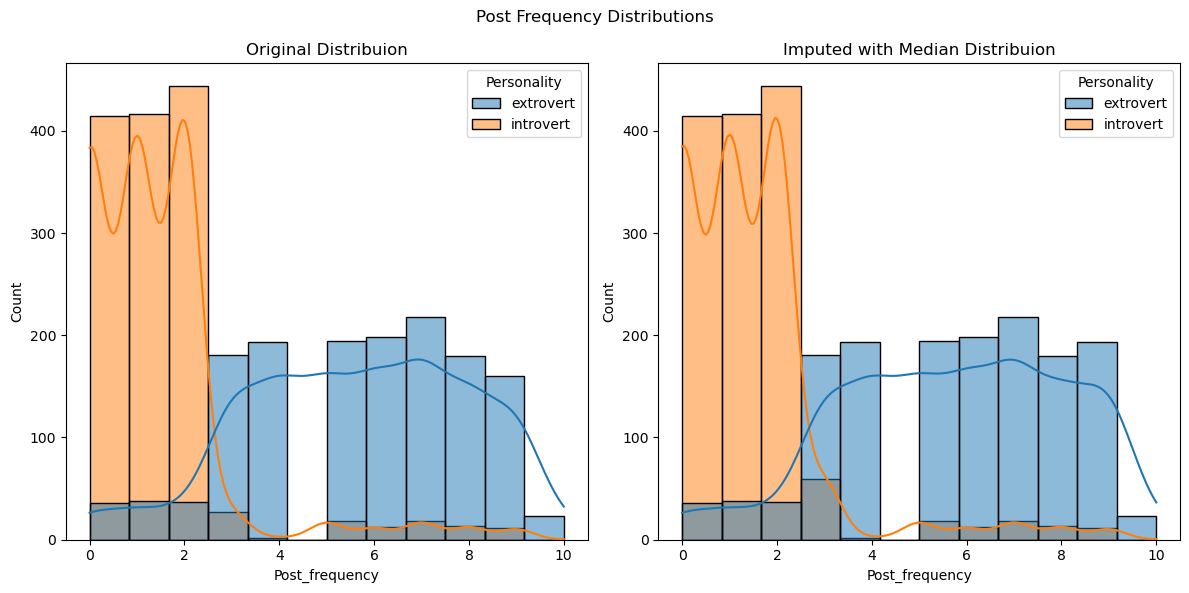

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), tight_layout=True)
plt.suptitle("Post Frequency Distributions")

bins = 12

sns.histplot(data=df, x="Post_frequency", hue="Personality", bins=bins, kde=True, ax=ax1)
ax1.set_title("Original Distribuion")

sns.histplot(data=df_clean, x="Post_frequency", hue="Personality", bins=bins, kde=True, ax=ax2)
ax2.set_title("Imputed with Median Distribuion")

Text(0.5, 1.0, 'Going Outside Distribution by Personality')

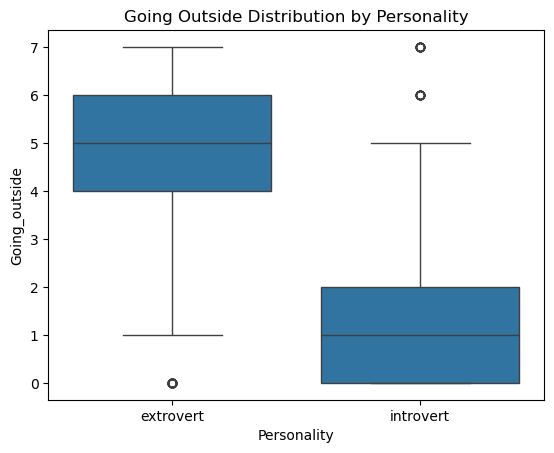

In [29]:
sns.boxplot(
    data=df_clean,
    y="Going_outside",
    x="Personality"
)
plt.title("Going Outside Distribution by Personality")

In [30]:
introverts_median_post_frequency = df_clean.loc[(df_clean['Personality'] == "introvert"), "Going_outside"].median()
extroverts_median_post_frequency = df_clean.loc[(df_clean['Personality'] == "extrovert"), "Going_outside"].median()

df_clean.loc[
    (df_clean['Personality'] == "introvert") & (df_clean['Going_outside'].isnull()),
    'Going_outside'
] = introverts_median_friends_circle_size
df_clean.loc[
    (df_clean['Personality'] == "extrovert") & (df_clean['Going_outside'].isnull()),
    'Going_outside'
] = extroverts_median_friends_circle_size

print(df_clean.loc[:, 'Going_outside'].isnull().sum())
df_clean.head()

0


,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,no,4.0,6.0,no,13.0,5.0,extrovert
1,9.0,yes,0.0,0.0,yes,0.0,3.0,introvert
2,9.0,yes,1.0,2.0,yes,5.0,2.0,introvert
3,0.0,no,6.0,7.0,no,14.0,8.0,extrovert
4,3.0,no,9.0,4.0,no,8.0,5.0,extrovert


In [31]:
print(pr.missing_value_table(df_clean)) # no missing values remaind, dataset is clean
df = df_clean

Shape of the dataset: (2900, 8)
Number of Features with Missing Values: 0
                           Missing Count  Missing Percentage
Time_spent_Alone                       0                 0.0
Stage_fear                             0                 0.0
Social_event_attendance                0                 0.0
Going_outside                          0                 0.0
Drained_after_socializing              0                 0.0
Friends_circle_size                    0                 0.0
Post_frequency                         0                 0.0
Personality                            0                 0.0


Text(0.5, 1.0, 'Missing Values Matrix Plot After Cleaning')

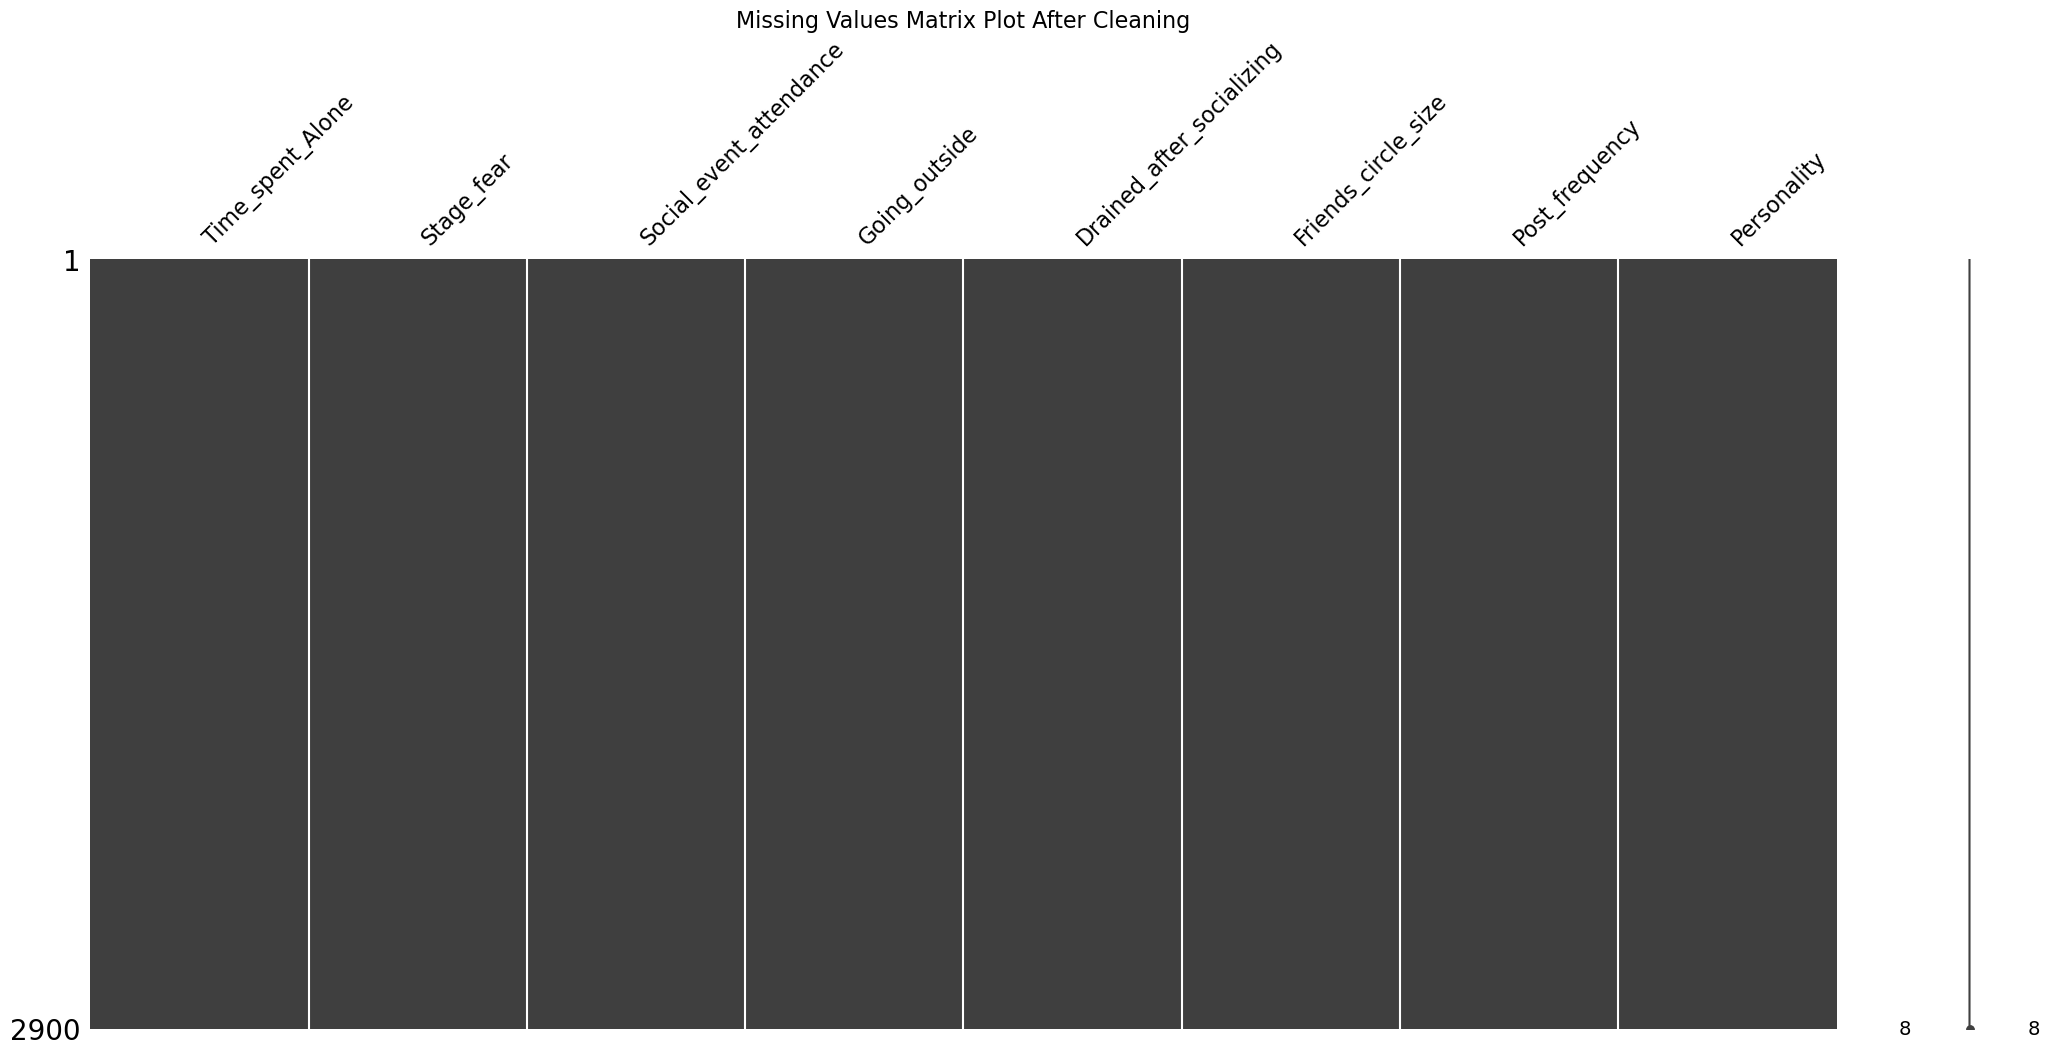

In [32]:
missingno.matrix(df)
plt.title("Missing Values Matrix Plot After Cleaning", fontsize=16)

In this section we clean the dataset. The approach was to impute suitable values for each null value in each feature based-on the personality type average cause this method can prevent resultant spikes in the distributions plot on a certain values and makes our feature distribuions more smooth that imputing the globaly averages.

### <a id='toc1_3_'></a>[1.3. De-Duplication](#toc0_)

In [33]:
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,no,4.0,6.0,no,13.0,5.0,extrovert
1,9.0,yes,0.0,0.0,yes,0.0,3.0,introvert
2,9.0,yes,1.0,2.0,yes,5.0,2.0,introvert
3,0.0,no,6.0,7.0,no,14.0,8.0,extrovert
4,3.0,no,9.0,4.0,no,8.0,5.0,extrovert


In [34]:
# avoiding semantic duplicates
assert df['Personality'].nunique() == 2, "There are more unique values"
assert df['Stage_fear'].nunique() == 2, "There are more unique values"
assert df['Drained_after_socializing'].nunique() == 2, "There are more unique values"

In [35]:
df[df.duplicated(keep=False)].sort_values(
    [
        "Stage_fear", "Drained_after_socializing", "Personality",
        "Time_spent_Alone", "Friends_circle_size"
	]
)

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
375,0.0,no,6.0,5.0,no,5.0,5.0,extrovert
2443,0.0,no,6.0,5.0,no,5.0,5.0,extrovert
364,0.0,no,4.0,5.0,no,6.0,3.0,extrovert
1213,0.0,no,4.0,4.0,no,6.0,5.0,extrovert
1434,0.0,no,4.0,6.0,no,6.0,6.0,extrovert
...,...,...,...,...,...,...,...,...
1357,11.0,yes,2.0,2.0,yes,5.0,0.0,introvert
2050,11.0,yes,2.0,2.0,yes,5.0,0.0,introvert
2240,11.0,yes,3.0,1.0,yes,5.0,2.0,introvert
2365,11.0,yes,3.0,2.0,yes,5.0,0.0,introvert


Using this method I find out that we can have samples that are from different persons but with the same information, cause in this dataset we don't have name, age, and other personal informations of the samples so we can't decide that these samples are duplicates or just similar informations from different people. I decide not to implement de-duplication task on this dataset and trust the data (I didn't saw any information about duplicates in this dataset in the kaggle desctiption of this dataset).

### <a id='toc1_4_'></a>[1.4. Handling Data-Irregularities](#toc0_)

Detecting outliers:
- statistical methods
	- z-score method
	- IQR method
- visualization methods
	- box plot
	- scatter plot
- machine learning methods
	- isolation forest algorithm
	- LOF (local outlier factor) algorithm

In [36]:
def detect_potential_outliers(
	df: pd.DataFrame,
    feature: str,
    method: str = "z-score",
    z_score_threshold: float = 3
) -> pd.Index:
    """Detect potential outliers using statistical methods
    
    This function used of the statmethods [z-score]

	:param df: _description_
	:type df: pd.DataFrame
	:param feature: _description_
	:type feature: str
	:param method: _description_, defaults to "z-score"
	:type method: str, optional
	:param z_score_threshold: _description_, defaults to 3
	:type z_score_threshold: float, optional
	:return: _description_
	:rtype: pd.Index
	"""
    if method == "z-score":
        mean_ = df[feature].mean()
        std_ = df[feature].std()
        z_score = abs((df[feature] - mean_) / std_)
        
        potential_outliers_indicies = df.loc[(z_score > z_score_threshold), feature].index
        
    if method.upper() == "IQR":
        iqr = df[feature].quantile(0.75) - df[feature].quantile(0.25)
        lower_fence = df[feature].quantile(0.25) - (1.5 * iqr)
        upper_fence = df[feature].quantile(0.75) + (1.5 * iqr)
        
        potential_outliers_indicies = df.loc[
            (df[feature] < lower_fence) | (df[feature] > upper_fence),
            feature
		].index

    return potential_outliers_indicies # potential outliers

In [37]:
feature = "Friends_circle_size"

indicies = detect_potential_outliers(df, feature=feature, method="iqr")
print(f"Number of potential outlier indicies: {len(indicies)}")
df.loc[indicies]

Number of potential outlier indicies: 0


,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality


**How to Handle Detected Outliers**

Once outliers are identified, you typically process them using one of these two approaches:

- **Removal (Filtering)**: Dropping the anomalies entirely. This gives you a cleaner dataset but results in a loss of sample size and potential loss of valuable rare events.

- **Capping (Winsorizing**): Replacing any values beyond the bounds with the exact value of the nearest fence (e.g., changing values above the upper fence to the upper fence value). This preserves sample size but alters the original dataset.